<a href="https://colab.research.google.com/github/sylwiabanasik/Praca_dyplomowa_SGH/blob/main/0_Analiza_Danych.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import bibliotek i danych

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn import  datasets, preprocessing
from pandas.plotting import radviz, scatter_matrix
from scipy.stats import spearmanr

plt.style.use('ggplot')
params = {
        'font.size': 12,
        'ytick.labelsize': 5,
        'xtick.labelsize': 5,
        'figure.figsize': (8,6)
          }
pylab.rcParams.update(params)

In [ ]:
#%%     import data
wine = datasets.load_wine()
#%%     changing feature names
wine.feature_names=['alco', 'mali', 'ash', 'alca', 'magn', 'phen', 'flav', 'nflav', 'proa', 'colo', 'hue', 'od280', 'prol']
#%%     create DataFrame
DataFrame = pd.DataFrame(data=np.asarray(np.c_[wine.data, wine.target]), \
                         columns=['alco', 'mali', 'ash', 'alca', 'magn', 'phen', 'flav', 'nflav', \
                                  'proa', 'colo', 'hue', 'od280', 'prol','class'])
DataFrame['class']=DataFrame['class'].astype('category')
#DataFrame.dtypes



In [ ]:
print('Zmiana nazw zmiennych: ')
print(' alcohol = alco, \n malic_acid = mali,\n ash = ash,\n alcalinity_of_ash = alca,\n magnesium = magn,')
print(' total_phenols = phen,\n flavanoids = flav,\n nonflavanoid_phenols = nflav,\n proanthocyanins = proa,')
print(' color_intensity = colo,\n hue = hue,\n od280/od315_of_diluted_wines =od280,\n proline = prol,\n class = class')

Zmiana nazw zmiennych: 
 alcohol = alco, 
 malic_acid = mali,
 ash = ash,
 alcalinity_of_ash = alca,
 magnesium = magn,
 total_phenols = phen,
 flavanoids = flav,
 nonflavanoid_phenols = nflav,
 proanthocyanins = proa,
 color_intensity = colo,
 hue = hue,
 od280/od315_of_diluted_wines =od280,
 proline = prol,
 class = class


# Analiza danych

In [ ]:
#%% describe data
print(DataFrame.describe())

             alco        mali         ash        alca        magn        phen  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean    13.000618    2.336348    2.366517   19.494944   99.741573    2.295112   
std      0.811827    1.117146    0.274344    3.339564   14.282484    0.625851   
min     11.030000    0.740000    1.360000   10.600000   70.000000    0.980000   
25%     12.362500    1.602500    2.210000   17.200000   88.000000    1.742500   
50%     13.050000    1.865000    2.360000   19.500000   98.000000    2.355000   
75%     13.677500    3.082500    2.557500   21.500000  107.000000    2.800000   
max     14.830000    5.800000    3.230000   30.000000  162.000000    3.880000   

             flav       nflav        proa        colo         hue       od280  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean     2.029270    0.361854    1.590899    5.058090    0.957449    2.611685   
std      0.998859    0.1244

In [ ]:
print('Var:')
DataFrame.var(axis=0,numeric_only=True)
print(DataFrame.var(axis=0,numeric_only=True))
#var_df = DataFrame.var(axis=0, numeric_only=True)
#print(var_df.to_frame().T)

print('\n\nVariance by class:')
print(DataFrame.groupby('class').var())

Var:
alco         0.659062
mali         1.248015
ash          0.075265
alca        11.152686
magn       203.989335
phen         0.391690
flav         0.997719
nflav        0.015489
proa         0.327595
colo         5.374449
hue          0.052245
od280        0.504086
prol     99166.717355
dtype: float64


Variance by class:
           alco      mali       ash       alca        magn      phen  \
class                                                                  
0.0    0.213560  0.474100  0.051604   6.483758  110.227937  0.114895   
1.0    0.289406  1.031380  0.099520  11.220962  280.679678  0.297419   
2.0    0.281156  1.183539  0.034110   5.099291  118.602394  0.127428   

           flav     nflav      proa      colo       hue     od280  \
class                                                               
0.0    0.158001  0.004907  0.169834  1.534063  0.013568  0.127504   
1.0    0.498014  0.015366  0.362486  0.855494  0.041183  0.246585   
2.0    0.086145  0.015411  0.167147 

/tmp/ipython-input-2867413324.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(DataFrame.groupby('class').var())


In [ ]:
print('Mean:')
print(DataFrame.mean(axis=0,numeric_only=True))
print('Mean by class:')
print(DataFrame.groupby('class').mean())

Mean:
alco      13.000618
mali       2.336348
ash        2.366517
alca      19.494944
magn      99.741573
phen       2.295112
flav       2.029270
nflav      0.361854
proa       1.590899
colo       5.058090
hue        0.957449
od280      2.611685
prol     746.893258
dtype: float64
Mean by class:
            alco      mali       ash       alca        magn      phen  \
class                                                                   
0.0    13.744746  2.010678  2.455593  17.037288  106.338983  2.840169   
1.0    12.278732  1.932676  2.244789  20.238028   94.549296  2.258873   
2.0    13.153750  3.333750  2.437083  21.416667   99.312500  1.678750   

           flav     nflav      proa      colo       hue     od280         prol  
class                                                                           
0.0    2.982373  0.290000  1.899322  5.528305  1.062034  3.157797  1115.711864  
1.0    2.080845  0.363662  1.630282  3.086620  1.056282  2.785352   519.507042  
2.0    0.78145

/tmp/ipython-input-3680696248.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(DataFrame.groupby('class').mean())


In [ ]:
print('Std:')
print(DataFrame.std(axis=0,numeric_only=True))
print('Std by class:')
print(DataFrame.groupby('class').std())

Std:
alco       0.811827
mali       1.117146
ash        0.274344
alca       3.339564
magn      14.282484
phen       0.625851
flav       0.998859
nflav      0.124453
proa       0.572359
colo       2.318286
hue        0.228572
od280      0.709990
prol     314.907474
dtype: float64
Std by class:
           alco      mali       ash      alca       magn      phen      flav  \
class                                                                          
0.0    0.462125  0.688549  0.227166  2.546322  10.498949  0.338961  0.397494   
1.0    0.537964  1.015569  0.315467  3.349770  16.753497  0.545361  0.705701   
2.0    0.530241  1.087906  0.184690  2.258161  10.890473  0.356971  0.293504   

          nflav      proa      colo       hue     od280        prol  
class                                                                
0.0    0.070049  0.412109  1.238573  0.116483  0.357077  221.520767  
1.0    0.123961  0.602068  0.924929  0.202937  0.496573  157.211220  
2.0    0.124140  0.408836

/tmp/ipython-input-741929452.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(DataFrame.groupby('class').std())


In [ ]:
print('Coefficient of variation: ')
print(DataFrame.std(axis=0,numeric_only=True).div(DataFrame.mean(axis=0,numeric_only=True),axis=0))
print('Coefficient of variation by class: ')
print(DataFrame.groupby('class').std().div(DataFrame.groupby('class').mean(),axis='columns'))

Coefficient of variation: 
alco     0.062445
mali     0.478159
ash      0.115927
alca     0.171304
magn     0.143195
phen     0.272689
flav     0.492226
nflav    0.343933
proa     0.359771
colo     0.458332
hue      0.238730
od280    0.271851
prol     0.421623
dtype: float64
Coefficient of variation by class: 
           alco      mali       ash      alca      magn      phen      flav  \
class                                                                         
0.0    0.033622  0.342446  0.092510  0.149456  0.098731  0.119345  0.133281   
1.0    0.043813  0.525473  0.140533  0.165519  0.177193  0.241431  0.339141   
2.0    0.040311  0.326331  0.075783  0.105439  0.109659  0.212641  0.375585   

          nflav      proa      colo       hue     od280      prol  
class                                                              
0.0    0.241549  0.216977  0.224042  0.109679  0.113078  0.198547  
1.0    0.340870  0.369303  0.299658  0.192124  0.178280  0.302616  
2.0    0.277407  0.3

/tmp/ipython-input-3411686662.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(DataFrame.groupby('class').std().div(DataFrame.groupby('class').mean(),axis='columns'))
/tmp/ipython-input-3411686662.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(DataFrame.groupby('class').std().div(DataFrame.groupby('class').mean(),axis='columns'))


# Analiza wykresowa

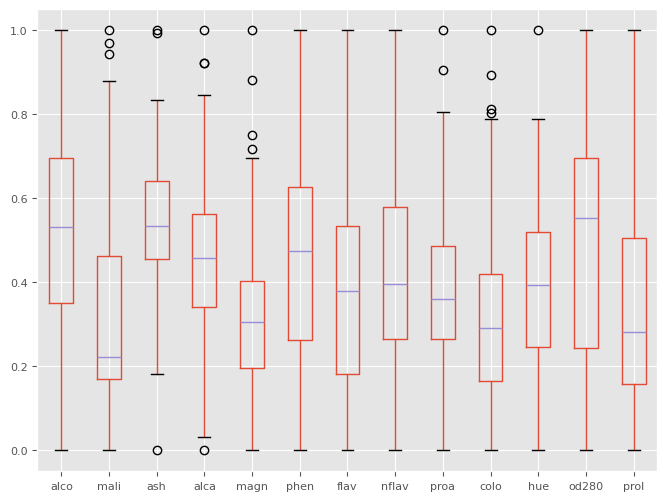

In [ ]:
plt.style.use('ggplot')
pylab.rcParams.update({'xtick.labelsize': 8,'ytick.labelsize': 8})

min_max_scaler = preprocessing.MinMaxScaler()
DataFrame_scaled =pd.DataFrame(data=min_max_scaler.fit_transform(DataFrame.values[:,0:13]), \
                               columns=DataFrame.columns[0:13])
DataFrame_scaled.boxplot()
plt.show()

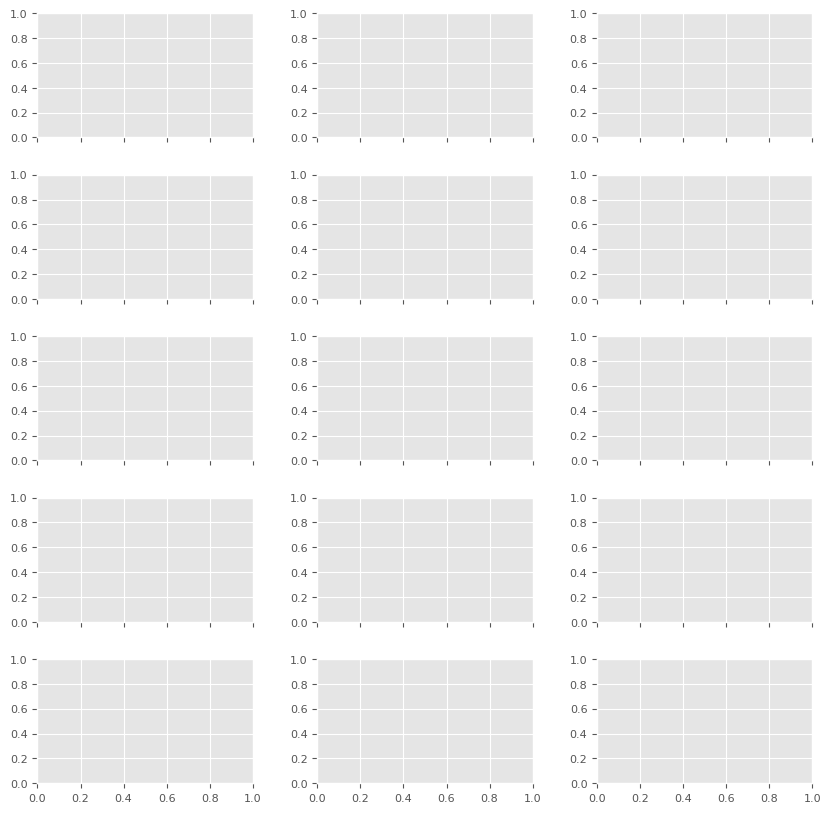

In [ ]:
plt.style.use('ggplot')
pylab.rcParams.update({'figure.figsize': (10,10),'font.size': 10,'axes.titlesize': 10, \
                       'xtick.labelsize': 8,'ytick.labelsize': 8,'axes.labelsize':-1})
fig, axes = plt.subplots(nrows=5, ncols=3, sharex=True)
fig.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

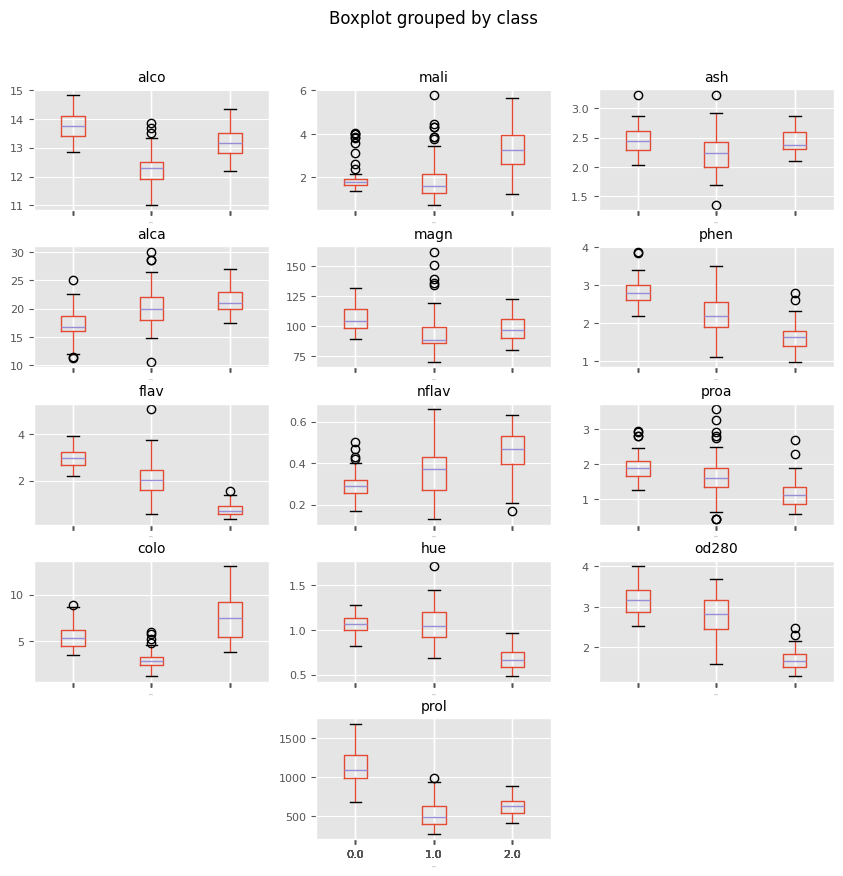

In [ ]:
plt.style.use('ggplot')
pylab.rcParams.update({'figure.figsize': (10,10),'font.size': 10,'axes.titlesize': 10, \
                       'xtick.labelsize': 8,'ytick.labelsize': 8,'axes.labelsize':-1})
fig, axes = plt.subplots(nrows=5, ncols=3, sharex=True)
fig.subplots_adjust(wspace=0.3, hspace=0.3)


df1=DataFrame.iloc[:,[0,13]]
df1.boxplot(by='class',ax=axes[0,0])
df2=DataFrame.iloc[:,[1,13]]
df2.boxplot(by='class',ax=axes[0,1])
df3=DataFrame.iloc[:,[2,13]]
df3.boxplot(by='class',ax=axes[0,2])
df4=DataFrame.iloc[:,[3,13]]
df4.boxplot(by='class',ax=axes[1,0])
df5=DataFrame.iloc[:,[4,13]]
df5.boxplot(by='class',ax=axes[1,1])
df6=DataFrame.iloc[:,[5,13]]
df6.boxplot(by='class',ax=axes[1,2])
df7=DataFrame.iloc[:,[6,13]]
df7.boxplot(by='class',ax=axes[2,0])
df8=DataFrame.iloc[:,[7,13]]
df8.boxplot(by='class',ax=axes[2,1])
df9=DataFrame.iloc[:,[8,13]]
df9.boxplot(by='class',ax=axes[2,2])
df10=DataFrame.iloc[:,[9,13]]
df10.boxplot(by='class',ax=axes[3,0])
df11=DataFrame.iloc[:,[10,13]]
df11.boxplot(by='class',ax=axes[3,1])
df12=DataFrame.iloc[:,[11,13]]
df12.boxplot(by='class',ax=axes[3,2])
df13=DataFrame.iloc[:,[12,13]]
df13.boxplot(by='class',ax=axes[4,1])
axes[4,0].axis('off')
axes[4,2].axis('off')
plt.show()

[np.float64(0.328), np.float64(0.438), np.float64(0.05), np.float64(0.518), np.float64(0.209), np.float64(0.719), np.float64(0.847), np.float64(0.489), np.float64(0.499), np.float64(0.266), np.float64(0.617), np.float64(0.788), np.float64(0.634)]
[np.float64(0.354), np.float64(0.347), np.float64(0.054), np.float64(0.57), np.float64(0.25), np.float64(0.727), np.float64(0.855), np.float64(0.474), np.float64(0.571), np.float64(0.131), np.float64(0.617), np.float64(0.744), np.float64(0.576)]


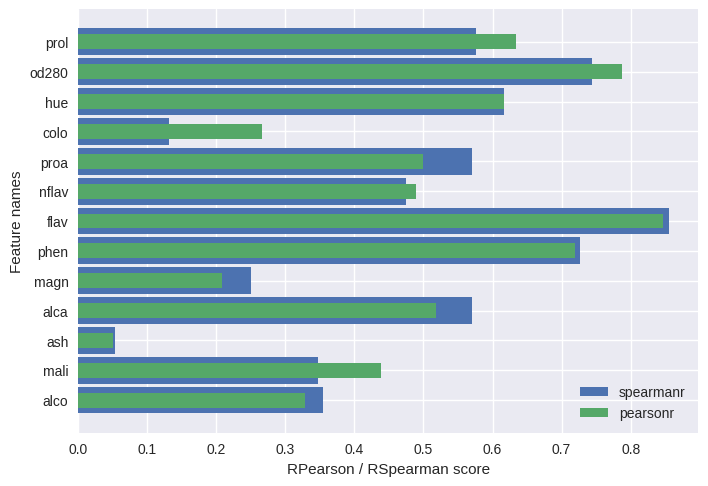

In [ ]:
#%% R Pearson RSpearman correlation (class)
plt.style.use('seaborn-v0_8')
lista_pearsonr =[]
lista_spearmanr =[]

for i in range(len(wine.feature_names)):
    if np.corrcoef(wine.target,wine.data[:,i])[1,0]<0:
        lista_pearsonr.append(-round(np.corrcoef(wine.target,wine.data[:,i])[1,0],3))
    else:
        lista_pearsonr.append(round(np.corrcoef(wine.target,wine.data[:,i])[1,0],3))
print(lista_pearsonr)

for i in range(len(wine.feature_names)):
    if spearmanr(wine.target,wine.data[:,i])[0]<0:
        lista_spearmanr.append(-round(spearmanr(wine.target,wine.data[:,i])[0],3))
    else:
        lista_spearmanr.append(round(spearmanr(wine.target,wine.data[:,i])[0],3))
print(lista_spearmanr)

plt.xlabel('RPearson / RSpearman score')
plt.ylabel('Feature names')
barh1 =plt.barh(range(len(wine.feature_names)), lista_spearmanr, align='center', height=0.9, label="spearmanr")
barh2 =plt.barh(range(len(wine.feature_names)), lista_pearsonr, align='center', height=0.5, label="pearsonr")
plt.yticks(np.arange(len(wine.feature_names)), wine.feature_names)
plt.legend(handles=[barh1, barh2])
plt.show()


In [ ]:

for i in np.arange(len(wine.feature_names)):
    print("PearsonR: ", lista_pearsonr[i]," SpearmanR: ",lista_spearmanr[i], " - ", wine.feature_names[i])
#%% heatmap plot
sns.set(style="white")

PearsonR:  0.328  SpearmanR:  0.354  -  alco
PearsonR:  0.438  SpearmanR:  0.347  -  mali
PearsonR:  0.05  SpearmanR:  0.054  -  ash
PearsonR:  0.518  SpearmanR:  0.57  -  alca
PearsonR:  0.209  SpearmanR:  0.25  -  magn
PearsonR:  0.719  SpearmanR:  0.727  -  phen
PearsonR:  0.847  SpearmanR:  0.855  -  flav
PearsonR:  0.489  SpearmanR:  0.474  -  nflav
PearsonR:  0.499  SpearmanR:  0.571  -  proa
PearsonR:  0.266  SpearmanR:  0.131  -  colo
PearsonR:  0.617  SpearmanR:  0.617  -  hue
PearsonR:  0.788  SpearmanR:  0.744  -  od280
PearsonR:  0.634  SpearmanR:  0.576  -  prol


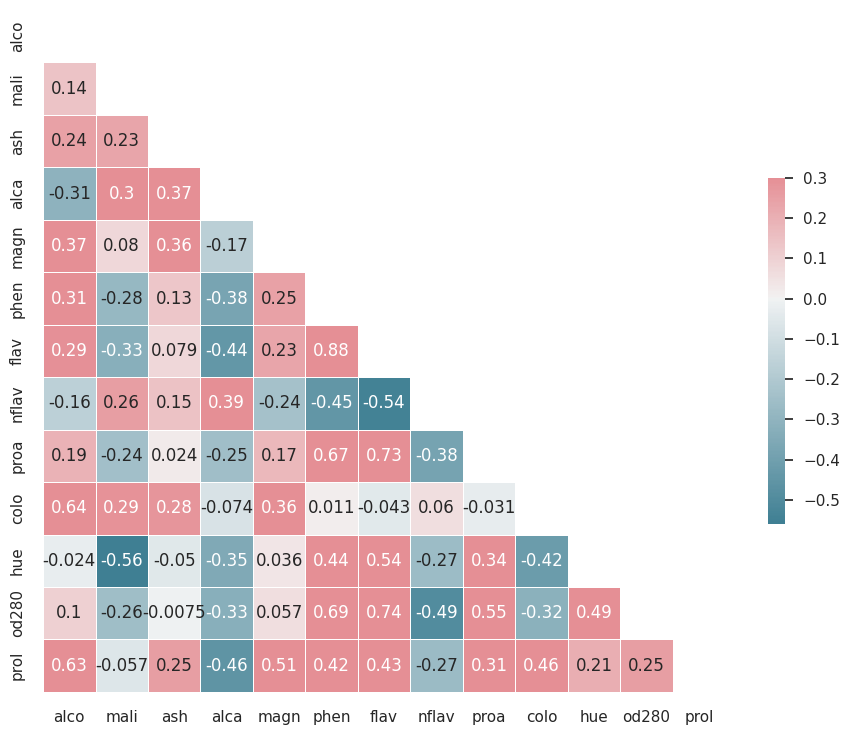

In [ ]:
# Generate a large random dataset
#rs = np.random.RandomState(33)
d = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# Compute the correlation matrix
corr = d.corr(method='spearman')

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,annot=True, \
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

#print(pd.DataFrame(data=wine.data, columns=wine.feature_names).corr())

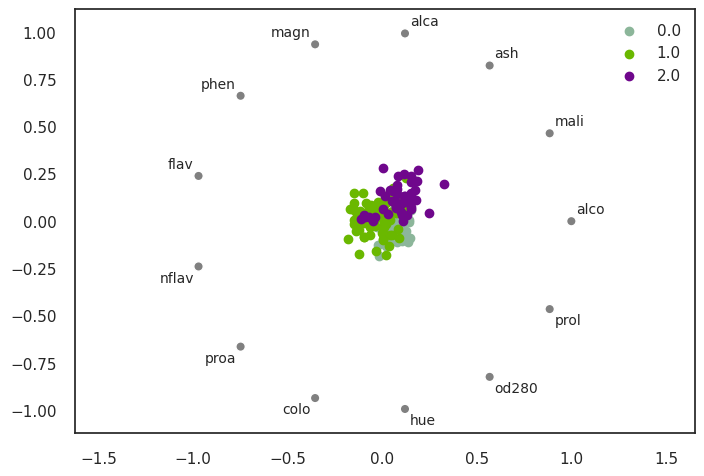

<Figure size 800x550 with 0 Axes>

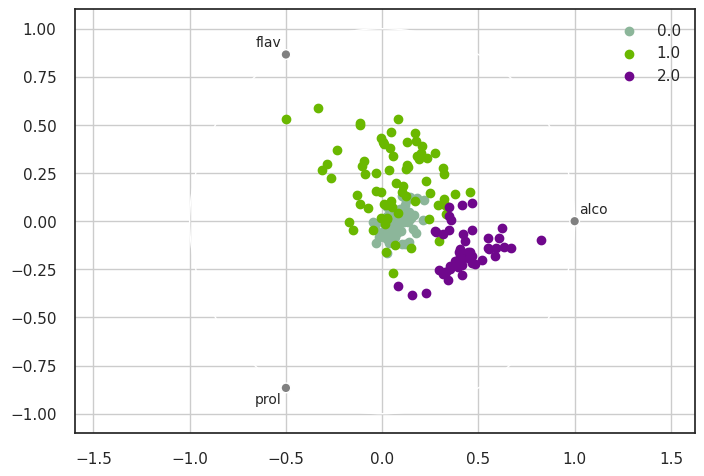

In [ ]:
#%% radviz plot
radviz(DataFrame.iloc[:,0:14],'class')
plt.figure()
plt.show()
#%%
radviz(DataFrame.iloc[:,[0,6,12,13]], 'class')
plt.grid()
plt.legend()
plt.show()

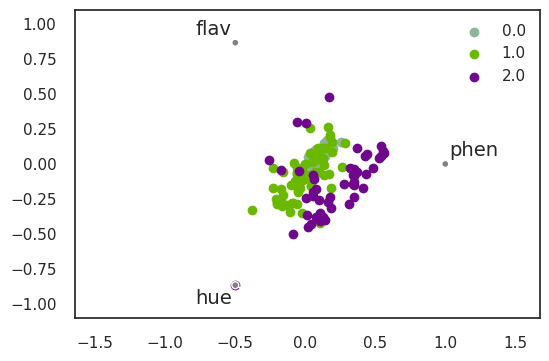

0 1 2 1


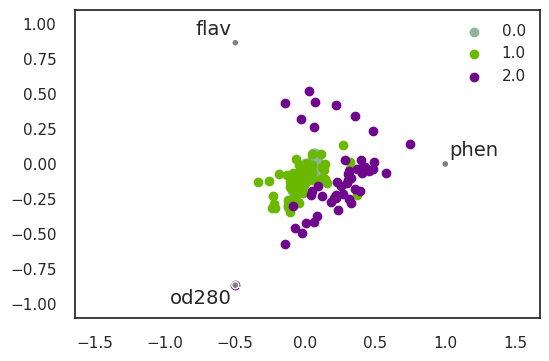

0 1 3 2


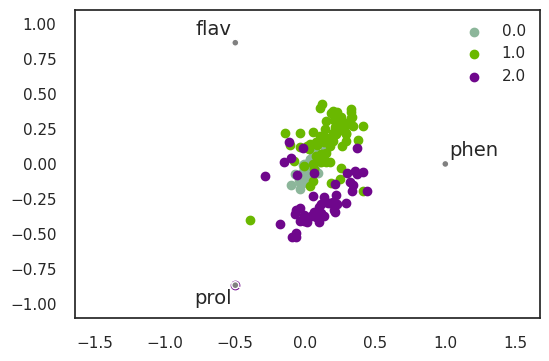

0 1 4 3


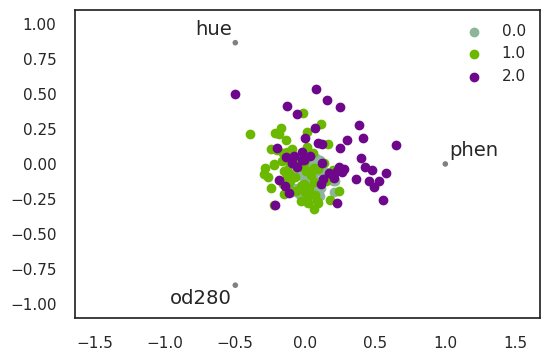

0 2 3 4


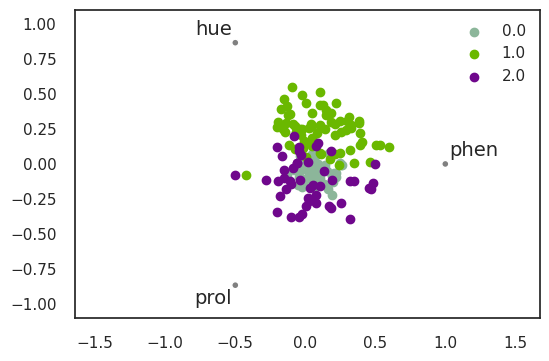

0 2 4 5


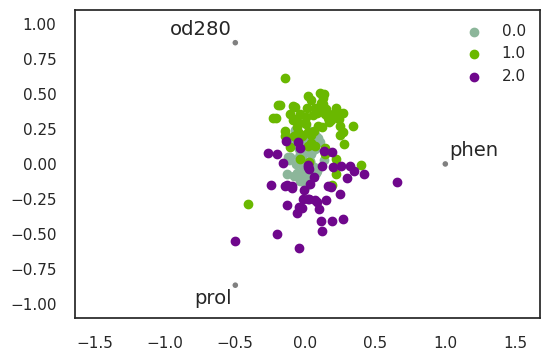

0 3 4 6


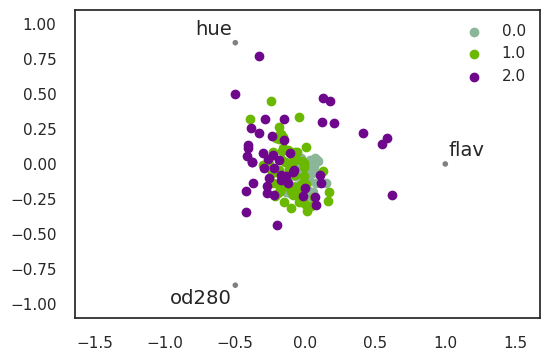

1 2 3 7


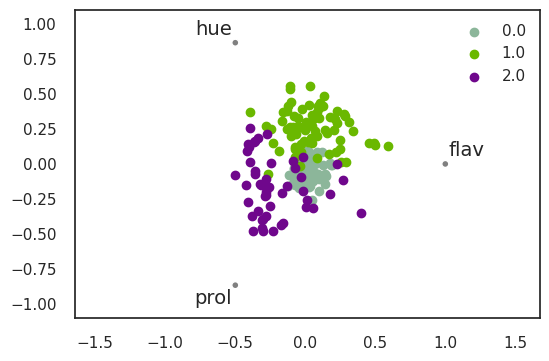

1 2 4 8


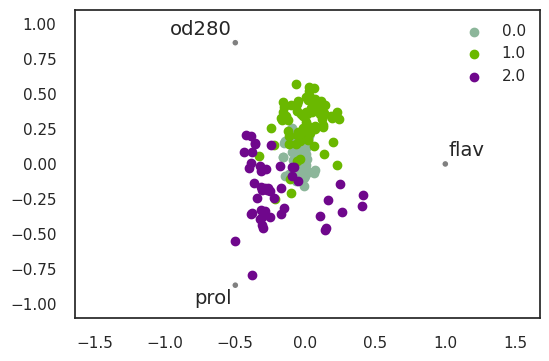

1 3 4 9


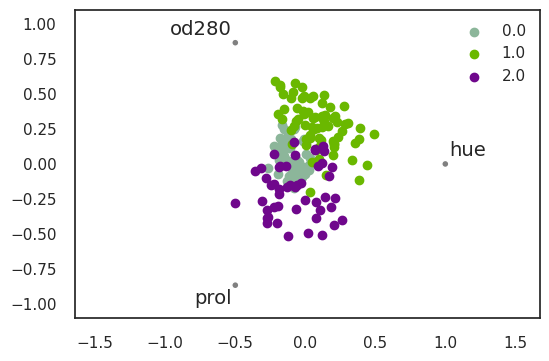

2 3 4 10


In [ ]:
pylab.rcParams.update({'figure.figsize': (6,4),'font.size': 17})
df1=DataFrame.iloc[:,[5,6,10,11,12,13]]
a=0
for i in range(len(df1.columns)-1):
    for j in range(len(df1.columns)-1):
        for k in range(len(df1.columns)-1):
            if i <j and j<k and i<k:
                plt.figure()
                radviz(df1.iloc[:,[i,j,k,5]], 'class')
                plt.show()
                plt.close()
                a=a+1
                print(i,j,k,a)

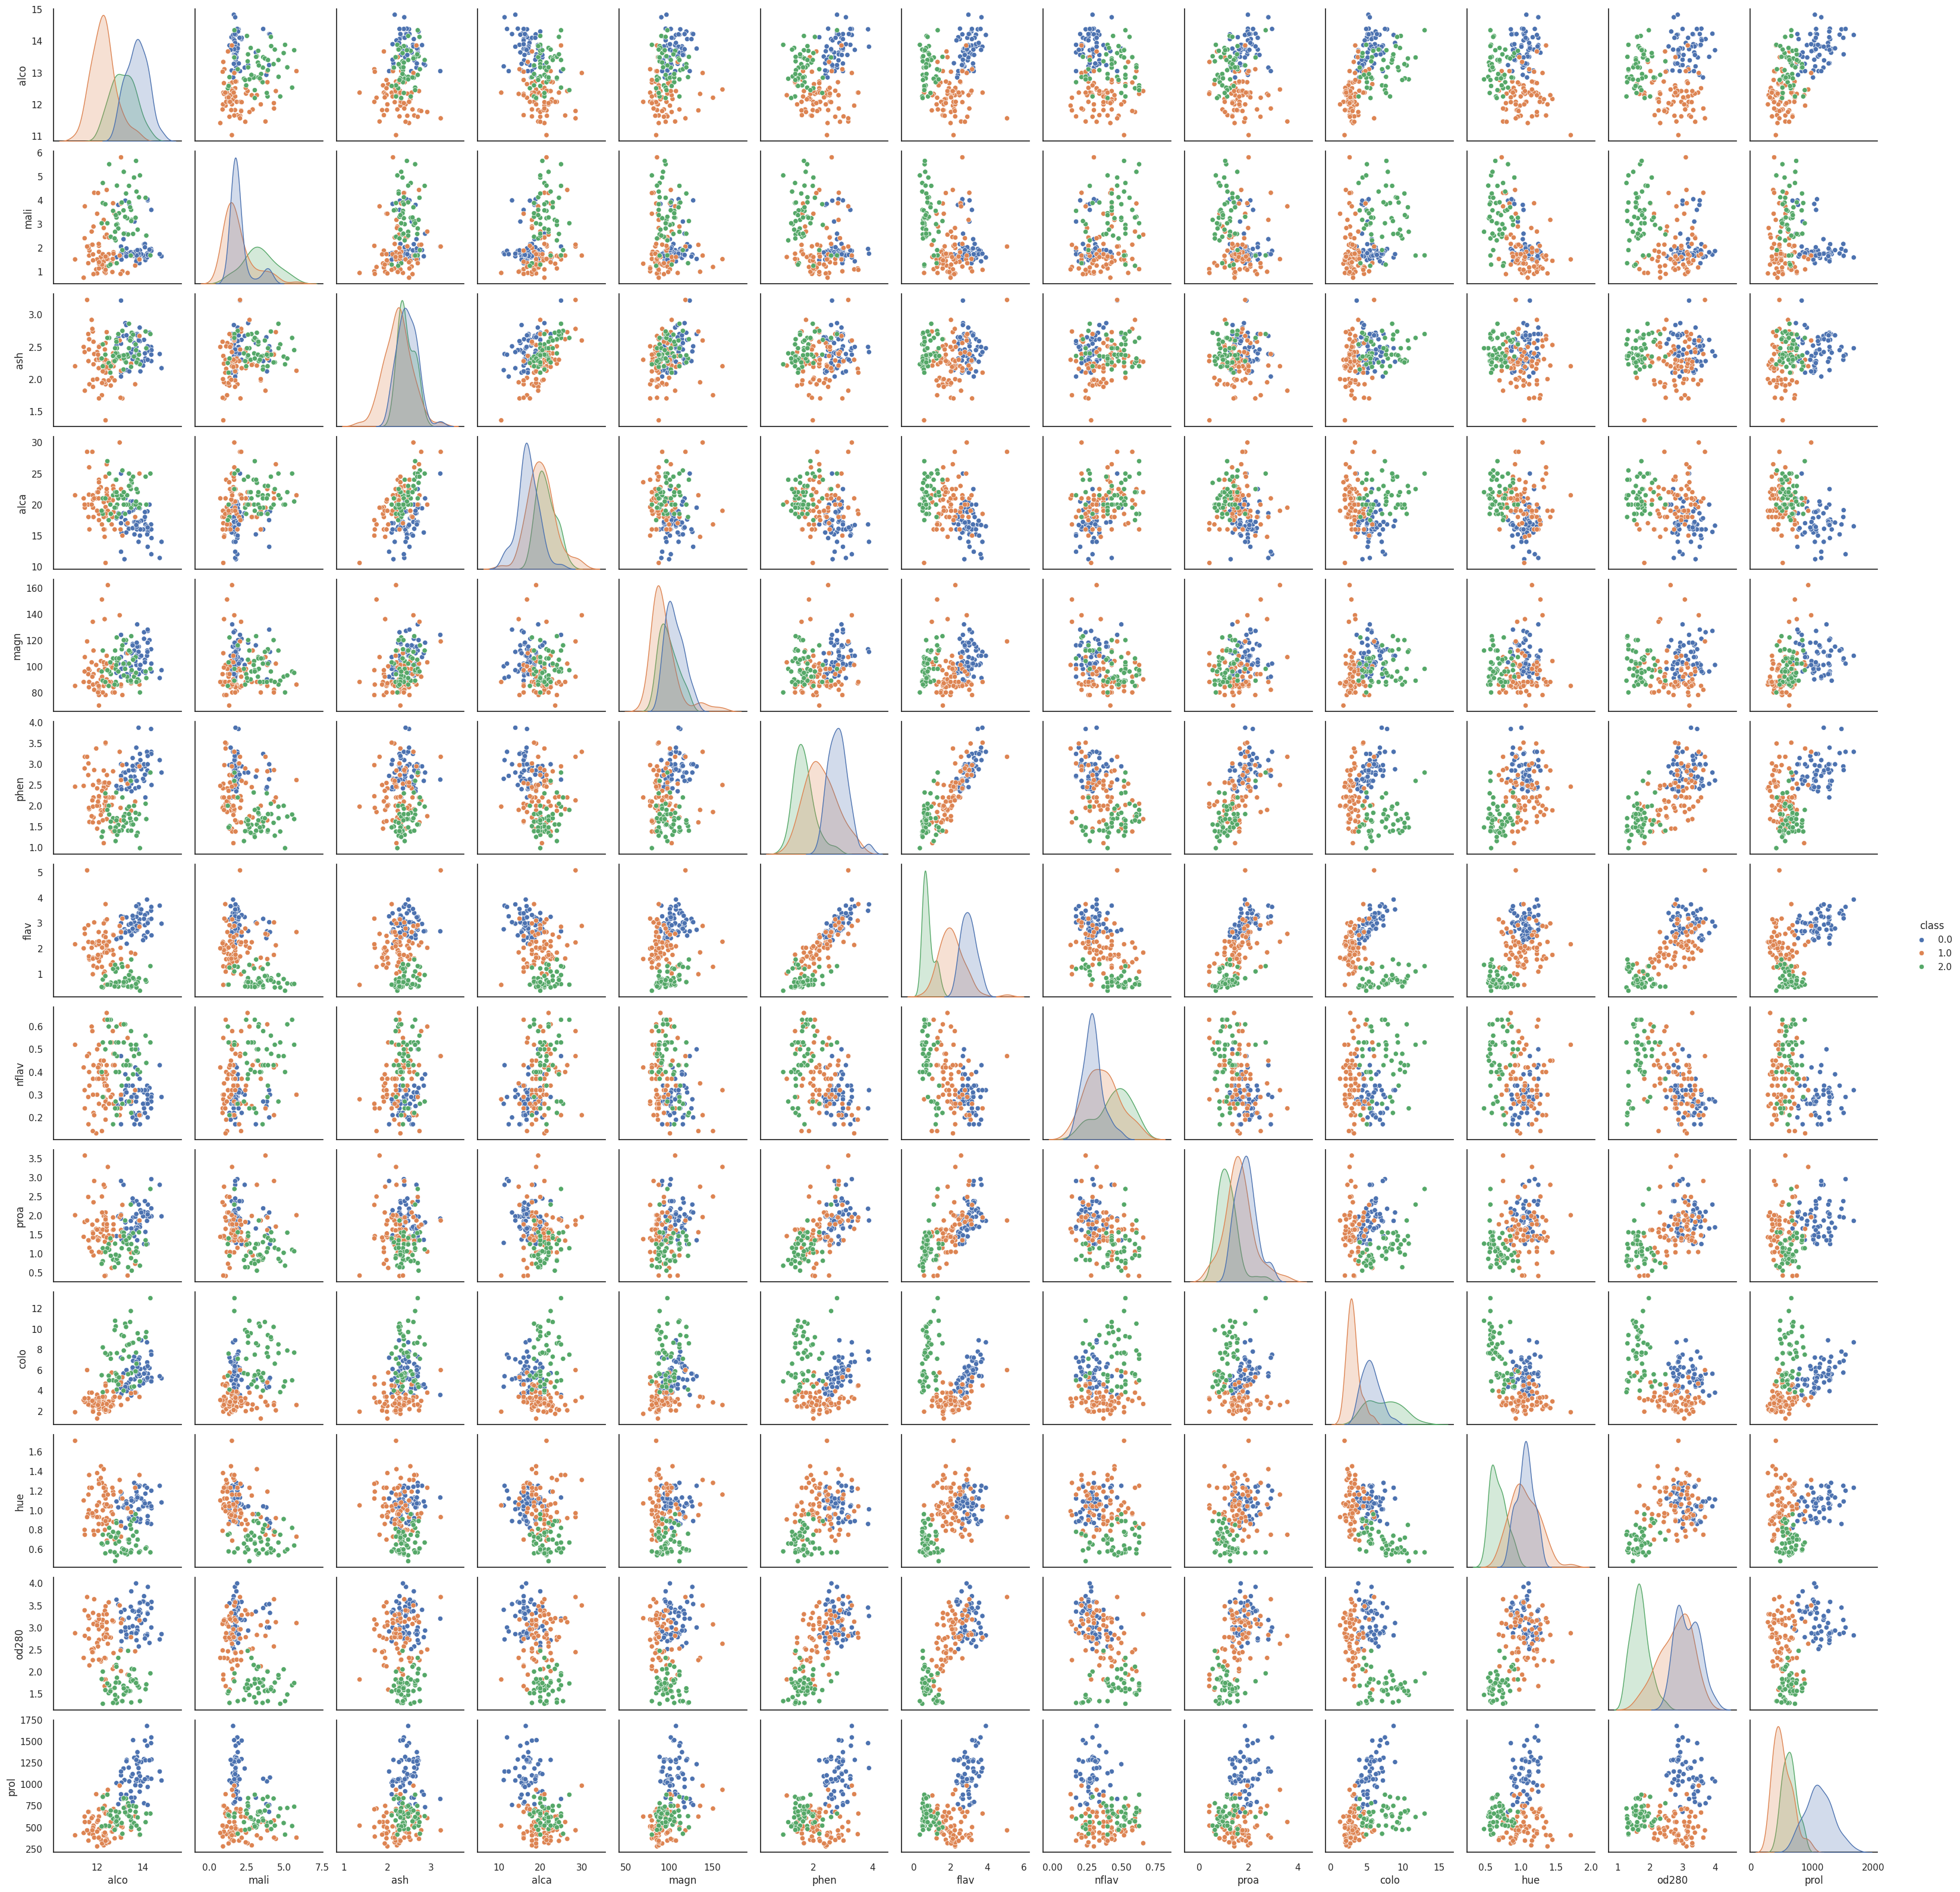

In [ ]:
#%% pairplot plot
sns.pairplot(data=DataFrame.iloc[:,0:14], hue="class")#[:,0:14]
plt.show()

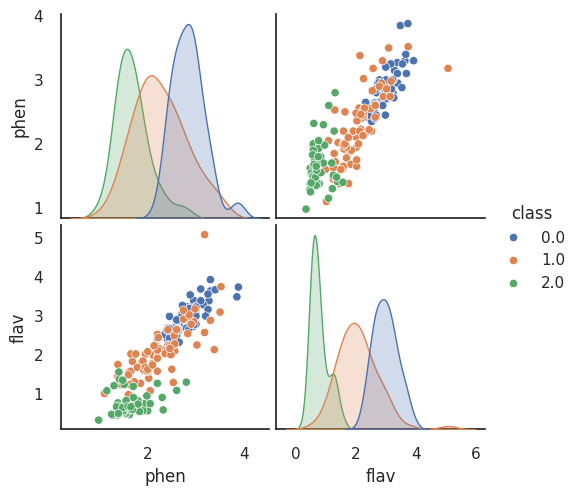

In [ ]:
#%%
pylab.rcParams.update({'figure.figsize': (7,5),'font.size': 10})
sns.pairplot(data=DataFrame.iloc[:,[5,6,13]], hue="class")#[:,[0,6,12,13]]
plt.show()

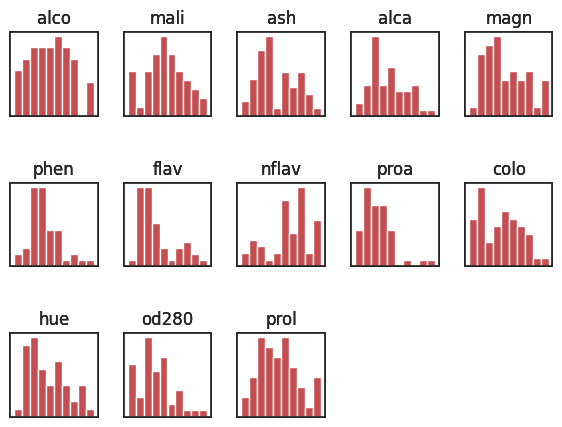

In [ ]:
#%% podzial danych ze wzgledu na skupienie: skupienie0, skupienie1, skupienie2
DATA = np.asarray(np.c_[wine.data, wine.target])
data_cl_0 = []
data_cl_1 = []
data_cl_2 = []

for i in range(DATA.shape[0]):
    if DATA[i,13]==0:
        data_cl_0.append(DATA[i,:])
    elif DATA[i,13]==1:
        data_cl_1.append(DATA[i,:])
    else:
        data_cl_2.append(DATA[i,:])

data_cl_0=np.asarray(data_cl_0)[:,0:13]
data_cl_1=np.asarray(data_cl_1)[:,0:13]
data_cl_2=np.asarray(data_cl_2)[:,0:13]

#%% wykresy histogramy (subplot) 3 hist na jednym wykresie
matplotlib.rcParams.update({'font.size': 4})
fig = plt.figure()
fig.subplots_adjust(wspace=0.3, hspace=0.8)

for i in range(len(wine.feature_names)):
    ax = fig.add_subplot(3,5,i+1)
    ax.set_title(wine.feature_names[i])
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.hist(data_cl_1[:,i],label='cl_1',facecolor='g')

for i in range(len(wine.feature_names)):
    ax = fig.add_subplot(3,5,i+1)
    ax.set_title(wine.feature_names[i])
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.hist(data_cl_0[:,i],label='cl_0',facecolor='b')

for i in range(len(wine.feature_names)):
    ax = fig.add_subplot(3,5,i+1)
    ax.set_title(wine.feature_names[i])
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.hist(data_cl_2[:,i],label='cl_2',facecolor='r')
plt.show()


<Figure size 1000x1000 with 0 Axes>

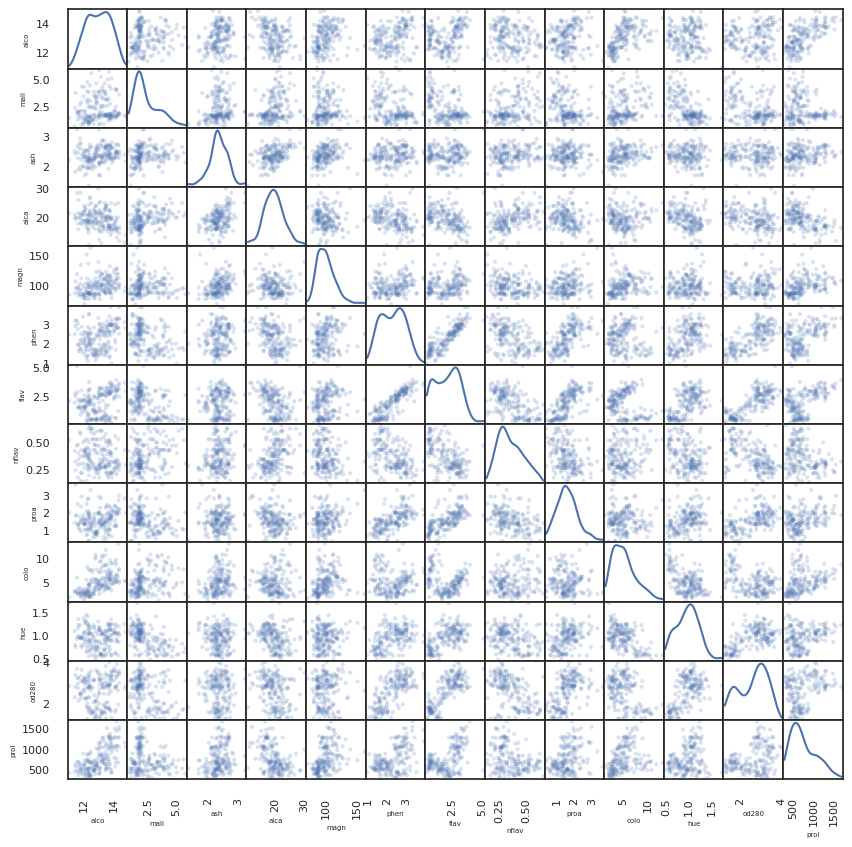

In [ ]:
#%%
pylab.rcParams.update({'figure.figsize': (10,10),'font.size': 10,'axes.titlesize': 10,'axes.labelsize':5})#'xtick.labelsize': 0,'ytick.labelsize': 0,
fig = plt.figure()
scatter_matrix(DataFrame, alpha=0.2, diagonal='kde')

plt.show()

In [ ]:
#%% wykresy histogramy (subplot)
#matplotlib.rcParams.update({'font.size': 3})
#fig = plt.figure()
#fig.subplots_adjust(wspace=0.15, hspace=0.6)
#count =0
#for i in range(len(wine.feature_names)):
#
#    ax = fig.add_subplot(14,3,count*3+1)
#
#    ax.set_title("Cl_0")
#    ax.set_yticklabels([])
#    ax.hist(data_cl_0[:,i],facecolor='g',density=1)
#
#    ax = fig.add_subplot(14,3,count*3+2)
#
#    ax.set_title("Cl_1")
#    ax.set_yticklabels([])
#    ax.hist(data_cl_1[:,i],facecolor='r',density=0)
#
#    ax = fig.add_subplot(14,3,count*3+3)
#
#    ax.set_title("Cl_2")
#    ax.set_yticklabels([])
#    ax.hist(data_cl_2[:,i],facecolor='b')
#    count=count+1
#plt.savefig('D:\kurs pyton\SGH\praca dyplomowa SGH\wykresy_hist_zmiennych2.pdf')
#plt.show()
#plt.close()
 #%% wykresy rozrzutu (pojedynczo)
#for i in range(len(wine.feature_names)):
#    plt.scatter(wine.data[:,i],wine.target)
#    plt.xlabel(wine.feature_names[i])
#    plt.ylabel('target')
#    plt.show()
#%%
#DataFrame.ndim
#DataFrame.shape

#%%
#DataFrame.groupby('class').hist()
#plt.savefig('D:\kurs pyton\SGH\praca dyplomowa SGH\wykres_grup_hist.pdf')
#%%
#fig = plt.figure()
#fig.subplots_adjust(wspace=0.3, hspace=0.8)
#n=1
#for i in DataFrame.columns[0:12]:
#    ax = fig.add_subplot(4,3,n)
#    #ax.set_subtitle(wine.feature_names[i])
#    ax.set_yticklabels([])
#    ax.set_xticklabels([])
#    #ax.set_ylabel(wine.feature_names[0:i])
#
#    DataFrame.groupby('class')[i].hist(alpha=0.4)
#    n=n+1
#plt.savefig('D:\kurs pyton\SGH\praca dyplomowa SGH\wykres_hist.pdf')

#%%
#from pandas.plotting import bootstrap_plot
#bootstrap_plot(DataFrame.flav, size=50, samples=50, color='grey')
#plt.savefig('D:\kurs pyton\SGH\praca dyplomowa SGH\wykres_bootstrap_plot.pdf')
#%%
#DataFrame.iloc[:,1].plot.kde()
#plt.show()
#DataFrame.iloc[:,1].plot.density()
#plt.show()
#DataFrame.iloc[:,1].plot.area()
#plt.show()
#DataFrame.iloc[:,1].plot.hist()
#plt.show()

#%%
#for i in range(14):
#    print(i)
#    print(DataFrame.columns[i])
 #%% wykresy rozrzutu (subplot)
#matplotlib.rcParams.update({'font.size': 3})
#fig = plt.figure()
#fig.subplots_adjust(wspace=0.3, hspace=0.8)
#for i in range(len(wine.feature_names)):
#    ax = fig.add_subplot(3,5,i+1)
#    ax.set_title(wine.feature_names[i])
#    ax.set_yticklabels([])
#    ax.scatter(wine.data[:,i],wine.target,s=0.5)

#plt.savefig(fname='D:\kurs pyton\SGH\praca dyplomowa SGH\wykresy_rozrzutu_zmiennych.pdf',orientation='landscape')
#plt.show()
#plt.close()
 #%%